In [1]:
print("""
====================================================================
L&T CreaTech Hackathon 2026: Operational Optimization Engine
By: Team Kaizen
Domain: Civil Infrastructure & Heavy Civil Engineering
Problem Statement 1: AI-Powered Cycle Time Optimization for Precast Yards
====================================================================

EXECUTIVE SUMMARY:
In precast concrete production, element cycle time-from casting to de-moulding-directly dictates project overhead, yard utilization, and capital allocation. Traditional maturity methods rely strictly on linear temperature tracking, failing to account for dynamic variables such as complex mix proportioning, ambient humidity (hydration efficiency), and site-specific handling logistics.

This script develops a comprehensive Decision-Support and Optimization Engine designed to solve this exact operational bottleneck.
""")


L&T CreaTech Hackathon 2026: Operational Optimization Engine
By: Team Kaizen
Domain: Civil Infrastructure & Heavy Civil Engineering
Problem Statement 1: AI-Powered Cycle Time Optimization for Precast Yards

EXECUTIVE SUMMARY:
In precast concrete production, element cycle time-from casting to de-moulding-directly dictates project overhead, yard utilization, and capital allocation. Traditional maturity methods rely strictly on linear temperature tracking, failing to account for dynamic variables such as complex mix proportioning, ambient humidity (hydration efficiency), and site-specific handling logistics.

This script develops a comprehensive Decision-Support and Optimization Engine designed to solve this exact operational bottleneck.



In [2]:
# ==========================================
# CELL 1: INITIALIZATION & FEATURE ENGINEERING
# ==========================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Initializing data pipeline and engineering structural features...")

# Load Dataset (Update path if necessary for Kaggle)
file_path = "/kaggle/input/datasets/soumyaranjansahoo33/concrete-data/Concrete_Data.csv" 
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("Error: Concrete_Data.csv not found. Ensure it is in the working directory.")

df.columns = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
              'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 
              'Age', 'Compressive_Strength']

# Domain-specific feature engineering for mix proportioning
df['Binder'] = df['Cement'] + df['Blast_Furnace_Slag'] + df['Fly_Ash']
df['Water_Binder_Ratio'] = df['Water'] / df['Binder']
df['Total_Aggregate'] = df['Coarse_Aggregate'] + df['Fine_Aggregate']
df['Aggregate_Binder_Ratio'] = df['Total_Aggregate'] / df['Binder']

# Define strict order for the model input
feature_cols = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
                'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 
                'Age', 'Binder', 'Water_Binder_Ratio', 'Total_Aggregate', 
                'Aggregate_Binder_Ratio']

X = df[feature_cols]
y = df['Compressive_Strength']

print(f"Dataset successfully processed. Shape: {X.shape[0]} samples, {X.shape[1]} features.")
print("Sample of engineered features (first 3 rows):")
display(X[['Binder', 'Water_Binder_Ratio', 'Total_Aggregate', 'Aggregate_Binder_Ratio']].head(3))

Initializing data pipeline and engineering structural features...
Dataset successfully processed. Shape: 1030 samples, 12 features.
Sample of engineered features (first 3 rows):


,Binder,Water_Binder_Ratio,Total_Aggregate,Aggregate_Binder_Ratio
0,540.0,0.30,1716.0,3.177778
1,540.0,0.30,1731.0,3.205556
2,475.0,0.48,1526.0,3.212632


In [3]:
# ==========================================
# CELL 2: MODEL TRAINING & EVALUATION
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Scaling features and training ensemble regression algorithms...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define Base Estimators
hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=7, random_state=42)
et = ExtraTreesRegressor(n_estimators=300, max_depth=15, min_samples_split=2, random_state=42)
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42)

# Construct Voting Regressor
ensemble_model = VotingRegressor(estimators=[('HistGB', hgb), ('ExtraTrees', et), ('GradientBoost', gb)])
ensemble_model.fit(X_train_scaled, y_train)

# Predict and Evaluate
predictions = ensemble_model.predict(X_test_scaled)
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"--- MODEL EVALUATION METRICS ---")
print(f"Validation Accuracy (R2): {r2:.4f}")
print(f"Error Margin (RMSE): {rmse:.2f} MPa")

Scaling features and training ensemble regression algorithms...
--- MODEL EVALUATION METRICS ---
Validation Accuracy (R2): 0.9287
Error Margin (RMSE): 4.29 MPa


Generating empirical validation plots...


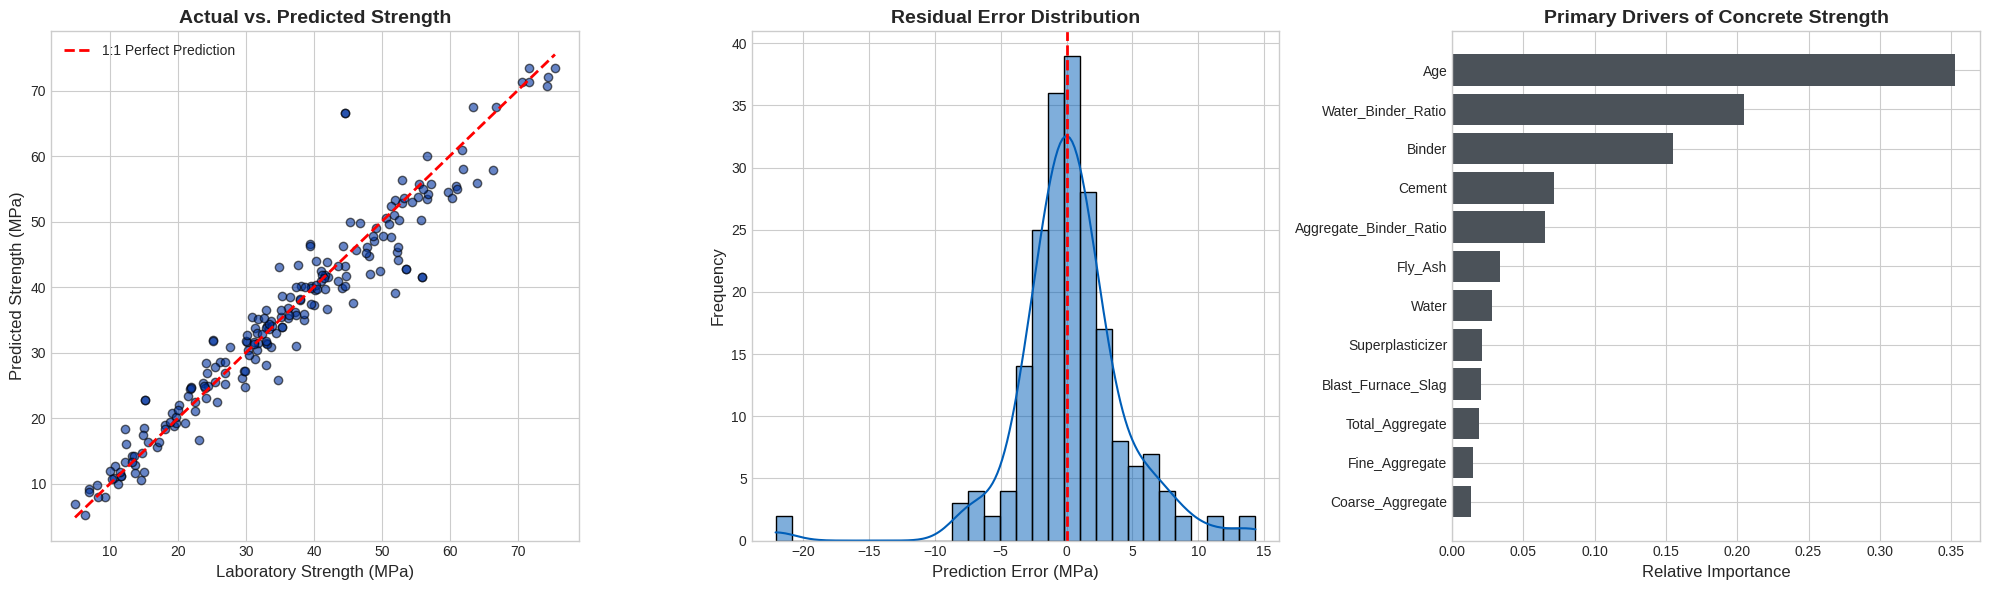

In [4]:
# ==========================================
# CELL 3: EMPIRICAL VALIDATION PLOTS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating empirical validation plots...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Actual vs. Predicted
axes[0].scatter(y_test, predictions, alpha=0.6, color='#0033a0', edgecolor='k')
min_val, max_val = min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Perfect Prediction')
axes[0].set_title('Actual vs. Predicted Strength', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Laboratory Strength (MPa)', fontsize=12)
axes[0].set_ylabel('Predicted Strength (MPa)', fontsize=12)
axes[0].legend()

# Plot 2: Residual Distribution
residuals = y_test - predictions
sns.histplot(residuals, kde=True, ax=axes[1], color='#005eb8', bins=30)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_title('Residual Error Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prediction Error (MPa)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Plot 3: Feature Importance
et_model = ensemble_model.named_estimators_['ExtraTrees']
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': et_model.feature_importances_}).sort_values(by='Importance', ascending=True)
axes[2].barh(feat_df['Feature'], feat_df['Importance'], color='#4b5259')
axes[2].set_title('Primary Drivers of Concrete Strength', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Relative Importance', fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# ==========================================
# CELL 4: OPERATIONAL CYCLE & CLIMATE ENGINE
# ==========================================
print("Initializing Operational Cost and Climate Simulation Engine...")

# Financial Constants
MATERIAL_COSTS = {
    'Cement': 0.12, 'Blast_Furnace_Slag': 0.05, 'Fly_Ash': 0.04, 
    'Water': 0.001, 'Superplasticizer': 2.50, 'Coarse_Aggregate': 0.02, 'Fine_Aggregate': 0.02
}

AUTOMATION_PROFILES = {
    'Manual': {'handling_days': 1.0, 'labor_rate': 40.0, 'equip_rate': 10.0},
    'Semi-Auto': {'handling_days': 0.5, 'labor_rate': 25.0, 'equip_rate': 30.0},
    'Fully-Auto': {'handling_days': 0.2, 'labor_rate': 10.0, 'equip_rate': 60.0}
}

STEAM_ENERGY_RATE = 20.00   

def calculate_material_cost(mix_design):
    return sum(mix_design.get(mat, 0) * price for mat, price in MATERIAL_COSTS.items())

def simulate_curing_cycle(model, scaler, base_mix, target_strength, temp_c, humidity_percent, automation_tier, is_steam=False):
    STANDARD_TEMP = 20.0 
    DATUM_TEMP = -10.0
    OPTIMAL_RH = 85.0
    
    temp_modifier = (temp_c - DATUM_TEMP) / (STANDARD_TEMP - DATUM_TEMP)
    humidity_modifier = humidity_percent / OPTIMAL_RH if humidity_percent < OPTIMAL_RH else 1.0
    auto_profile = AUTOMATION_PROFILES[automation_tier]
    
    binder = base_mix['Cement'] + base_mix['Blast_Furnace_Slag'] + base_mix['Fly_Ash']
    wb_ratio = base_mix['Water'] / binder
    tot_agg = base_mix['Coarse_Aggregate'] + base_mix['Fine_Aggregate']
    ab_ratio = tot_agg / binder
    
    for real_day in range(1, 29): 
        equivalent_age = real_day * temp_modifier * humidity_modifier
        
        feature_vector = [
            base_mix['Cement'], base_mix['Blast_Furnace_Slag'], base_mix['Fly_Ash'],
            base_mix['Water'], base_mix['Superplasticizer'], base_mix['Coarse_Aggregate'],
            base_mix['Fine_Aggregate'], equivalent_age, binder, wb_ratio, tot_agg, ab_ratio
        ]
        
        scaled_vector = scaler.transform([feature_vector])
        predicted_strength = model.predict(scaled_vector)[0]
        
        if predicted_strength >= target_strength:
            mat_cost = calculate_material_cost(base_mix)
            total_cycle_days = real_day + auto_profile['handling_days']
            
            labor_cost = total_cycle_days * auto_profile['labor_rate']
            equip_cost = total_cycle_days * auto_profile['equip_rate']
            energy_cost = (real_day * STEAM_ENERGY_RATE) if is_steam else 0.0
            
            total_cost = mat_cost + labor_cost + equip_cost + energy_cost
            costs = {'Material': mat_cost, 'Labor': labor_cost, 'Equipment': equip_cost, 'Energy': energy_cost, 'Total': total_cost}
            
            return real_day, total_cycle_days, predicted_strength, costs
            
    return None, None, None, None

print("Engine initialized successfully.")

Initializing Operational Cost and Climate Simulation Engine...
Engine initialized successfully.


In [6]:
# ==========================================
# CELL 5: MULTI-VARIABLE SCENARIO EXECUTION
# ==========================================
print("Executing Operational Matrix Simulation...")

sample_mix = {
    'Cement': 350.0, 'Blast_Furnace_Slag': 0.0, 'Fly_Ash': 100.0,
    'Water': 160.0, 'Superplasticizer': 5.0, 'Coarse_Aggregate': 1000.0, 'Fine_Aggregate': 750.0
}
target_str = 30.0 

climates = {
    'Winter_Dry (0C, 40% RH)': {'temp': 0.0, 'rh': 40.0, 'steam': False},
    'Standard_Ambient (20C, 60% RH)': {'temp': 20.0, 'rh': 60.0, 'steam': False},
    'Summer_Arid (35C, 20% RH)': {'temp': 35.0, 'rh': 20.0, 'steam': False},
    'Summer_Tropical (35C, 90% RH)': {'temp': 35.0, 'rh': 90.0, 'steam': False},
    'Steam_Chamber (65C, 100% RH)': {'temp': 65.0, 'rh': 100.0, 'steam': True}
}

automation_tiers = ['Manual', 'Semi-Auto', 'Fully-Auto']
results = []

for climate_name, conditions in climates.items():
    for tier in automation_tiers:
        curing_days, cycle_days, strength, cost = simulate_curing_cycle(
            ensemble_model, scaler, sample_mix, target_str, 
            conditions['temp'], conditions['rh'], tier, conditions['steam']
        )
        
        if curing_days:
            results.append({
                'Climate_Profile': climate_name,
                'Automation': tier,
                'Chemical_Curing_Days': curing_days,
                'Total_Cycle_Days': cycle_days,
                'Total_Cost_USD': cost['Total'],
                'Material_Cost': cost['Material'],
                'Labor_Cost': cost['Labor'],
                'Equip_Cost': cost['Equipment'],
                'Energy_Cost': cost['Energy']
            })

results_df = pd.DataFrame(results)

print(f"Simulation complete. Evaluated {len(climates) * len(automation_tiers)} theoretical scenarios.")

Executing Operational Matrix Simulation...
Simulation complete. Evaluated 15 theoretical scenarios.


In [7]:
# ==========================================
# CELL 6: OPTIMIZATION DIRECTIVE ANALYSIS
# ==========================================
print("--- MATRIX OUTPUT: TOP 5 EFFICIENT CONFIGURATIONS ---")
# Sort by lowest cost, then lowest cycle time
results_df = results_df.sort_values(by=['Total_Cost_USD', 'Total_Cycle_Days']).reset_index(drop=True)
display(results_df[['Climate_Profile', 'Automation', 'Total_Cycle_Days', 'Total_Cost_USD']].head(5))

optimal = results_df.iloc[0]

print("\n==============================================")
print("          FINAL ENGINEERING DIRECTIVE         ")
print("==============================================")
print(f"Target Demoulding Strength : {target_str} MPa")
print(f"Optimal Infrastructure     : {optimal['Automation']} Handling")
print(f"Optimal Climatic Procedure : {optimal['Climate_Profile']}")
print(f"----------------------------------------------")
print(f"Projected Element Cost     : ${optimal['Total_Cost_USD']:.2f}")
print(f"Relative Cycle Time        : {optimal['Total_Cycle_Days']} Days")
print("==============================================\n")

--- MATRIX OUTPUT: TOP 5 EFFICIENT CONFIGURATIONS ---


,Climate_Profile,Automation,Total_Cycle_Days,Total_Cost_USD
0,"Steam_Chamber (65C, 100% RH)",Semi-Auto,2.5,271.16
1,"Steam_Chamber (65C, 100% RH)",Manual,3.0,283.66
2,"Steam_Chamber (65C, 100% RH)",Fully-Auto,2.2,287.66
3,"Summer_Tropical (35C, 90% RH)",Semi-Auto,4.5,341.16
4,"Summer_Tropical (35C, 90% RH)",Manual,5.0,343.66



          FINAL ENGINEERING DIRECTIVE         
Target Demoulding Strength : 30.0 MPa
Optimal Infrastructure     : Semi-Auto Handling
Optimal Climatic Procedure : Steam_Chamber (65C, 100% RH)
----------------------------------------------
Projected Element Cost     : $271.16
Relative Cycle Time        : 2.5 Days



Generating Operational Trade-off Visualizations...


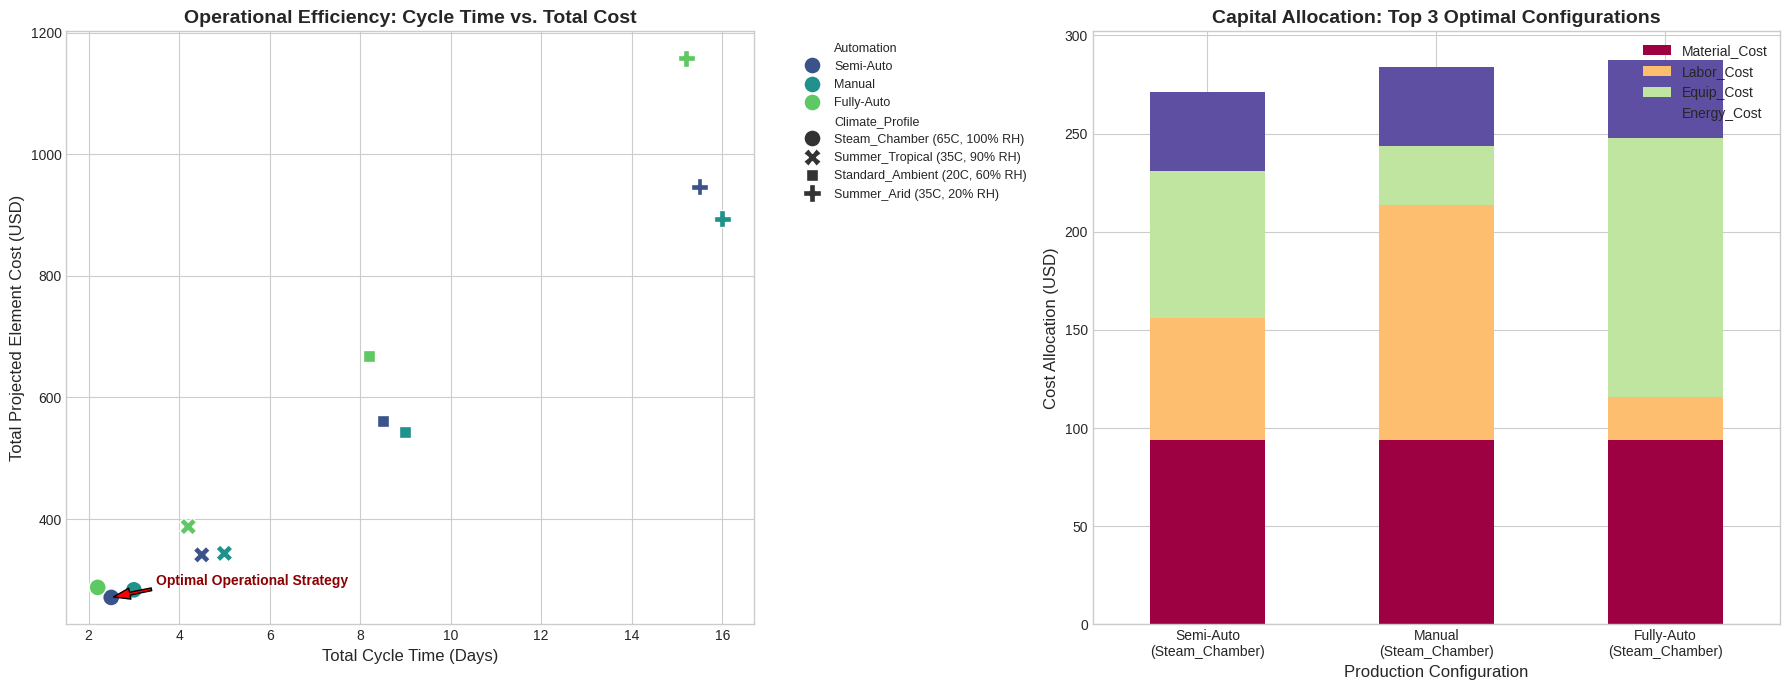

In [8]:
# ==========================================
# CELL 7: EXECUTIVE VISUAL ANALYTICS
# ==========================================
print("Generating Operational Trade-off Visualizations...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Cost vs. Cycle Time (Pareto Analysis)
sns.scatterplot(
    data=results_df, x='Total_Cycle_Days', y='Total_Cost_USD', 
    hue='Automation', style='Climate_Profile', s=150, palette='viridis', ax=ax1
)

# Highlight optimal configuration
ax1.annotate('Optimal Operational Strategy', 
             xy=(optimal['Total_Cycle_Days'], optimal['Total_Cost_USD']), 
             xytext=(optimal['Total_Cycle_Days'] + 1, optimal['Total_Cost_USD'] + 20),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             fontsize=10, fontweight='bold', color='darkred')

ax1.set_title('Operational Efficiency: Cycle Time vs. Total Cost', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Cycle Time (Days)', fontsize=12)
ax1.set_ylabel('Total Projected Element Cost (USD)', fontsize=12)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Plot 2: Cost Breakdown of Top 3 Configurations
top_3 = results_df.head(3).copy()
top_3['Config'] = top_3['Automation'] + "\n(" + top_3['Climate_Profile'].str.split(' ').str[0] + ")"
breakdown_df = top_3[['Config', 'Material_Cost', 'Labor_Cost', 'Equip_Cost', 'Energy_Cost']].set_index('Config')

breakdown_df.plot(kind='bar', stacked=True, colormap='Spectral', ax=ax2)
ax2.set_title('Capital Allocation: Top 3 Optimal Configurations', fontsize=14, fontweight='bold')
ax2.set_xlabel('Production Configuration', fontsize=12)
ax2.set_ylabel('Cost Allocation (USD)', fontsize=12)
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# CELL 8: MODEL EXPORT & SERIALIZATION
# ==========================================
import joblib

print("Exporting model components for production deployment...")
joblib.dump(ensemble_model, 'optimized_regression_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print("✅ 'optimized_regression_model.pkl' saved successfully.")
print("✅ 'feature_scaler.pkl' saved successfully.")
print("Pipeline execution complete.")

Exporting model components for production deployment...
✅ 'optimized_regression_model.pkl' saved successfully.
✅ 'feature_scaler.pkl' saved successfully.
Pipeline execution complete.
